In [5]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import numpy as np

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = np.stack([train_images]*3, axis=-1) / 255.0
test_images = np.stack([test_images]*3, axis=-1) / 255.0

train_images = tf.image.resize(train_images, [32, 32])
test_images = tf.image.resize(test_images, [32, 32])

train_labels = to_categorical(train_labels, 10)
test_labels = to_categorical(test_labels, 10)

I0000 00:00:1754431977.539995  153682 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4080 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 Ti with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5
2025-08-05 18:12:57.697362: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1128960000 exceeds 10% of free system memory.
2025-08-05 18:13:16.432641: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 188160000 exceeds 10% of free system memory.


In [9]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False  # Freeze base model

inputs = Input(shape=(32, 32, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(10, activation='softmax')(x)
model = Model(inputs, outputs)

/tmp/ipykernel_153682/3104373990.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 17s 2us/step


In [ ]:
# Initial training
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_images, train_labels, epochs=10, validation_split=0.2)

2025-08-05 18:17:16.665513: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 589824000 exceeds 10% of free system memory.


Epoch 1/10


I0000 00:00:1754432243.141598  154459 service.cc:152] XLA service 0x7c805c00de40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1754432243.141965  154459 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce GTX 1660 Ti with Max-Q Design, Compute Capability 7.5
2025-08-05 18:17:23.294652: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1754432244.104426  154459 cuda_dnn.cc:529] Loaded cuDNN version 90300


  16/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.1210 - loss: 2.3063

I0000 00:00:1754432247.590633  154459 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1497/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4388 - loss: 1.8403

2025-08-05 18:17:41.568338: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 147456000 exceeds 10% of free system memory.


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 13ms/step - accuracy: 0.5223 - loss: 1.5982 - val_accuracy: 0.6080 - val_loss: 1.3014
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.6171 - loss: 1.2230 - val_accuracy: 0.6356 - val_loss: 1.1418
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.6392 - loss: 1.1196 - val_accuracy: 0.6517 - val_loss: 1.0733
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.6507 - loss: 1.0691 - val_accuracy: 0.6593 - val_loss: 1.0372
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.6568 - loss: 1.0401 - val_accuracy: 0.6646 - val_loss: 1.0149
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.6605 - loss: 1.0209 - val_accuracy: 0.6680 - val_loss: 1.0010
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.6636 - loss: 1.0080 - val_accuracy: 0.6707 - val_loss: 0.9897
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.6654 - loss: 0.99

In [16]:
# Test metrics
loss, accuracy = model.evaluate(test_images, test_labels)
print(f"Test loss: {loss}")
print(f"Test accuracy: {accuracy}")

2025-08-05 18:21:52.165892: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 122880000 exceeds 10% of free system memory.


313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.6669 - loss: 0.9765
Test loss: 0.9764721393585205
Test accuracy: 0.6668999791145325


In [17]:
# Fine tuning
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_images, train_labels, epochs=5, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 20ms/step - accuracy: 0.3135 - loss: 6.9479 - val_accuracy: 0.1657 - val_loss: 8.8294
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.5076 - loss: 2.1973 - val_accuracy: 0.2804 - val_loss: 2.5388
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.6265 - loss: 1.3834 - val_accuracy: 0.6380 - val_loss: 1.1909
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.7056 - loss: 1.0623 - val_accuracy: 0.7888 - val_loss: 0.7519
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.7657 - loss: 0.8107 - val_accuracy: 0.8336 - val_loss: 0.6047


In [18]:
# Test metrics
loss, accuracy = model.evaluate(test_images, test_labels)
print(f"Test loss: {loss}")
print(f"Test accuracy: {accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8291 - loss: 0.6473
Test loss: 0.6473199725151062
Test accuracy: 0.8291000127792358


313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step


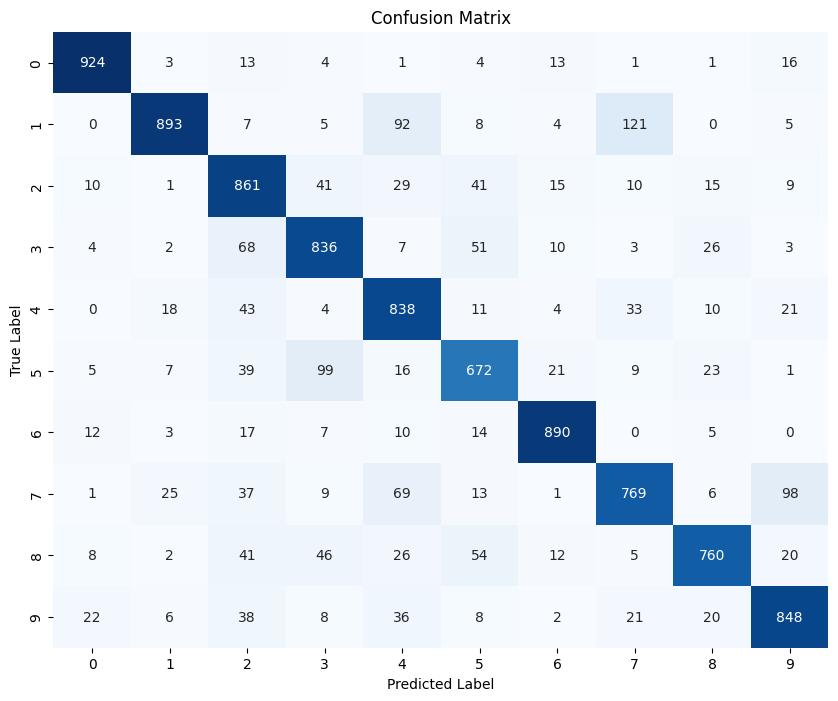

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_predictions = model.predict(test_images)
test_predictions_classes = np.argmax(test_predictions, axis=1)
test_true_classes = np.argmax(test_labels, axis=1)

cm = confusion_matrix(test_true_classes, test_predictions_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()